# Hurricane Milton: wind and SSH across products

The maintained helper produces the four-date, three-column projected figure:
L4 wind with vectors, L3 along-track SSH, and L3 SWOT. The dense SWOT product
is always requested; a missing source is shown as missing rather than hidden.

In [1]:
import os
import warnings
from io import BytesIO
from pathlib import Path

from IPython.display import Image, display

# Hub transfers report progress on stderr, which would otherwise be captured as
# notebook output and rendered as noise in the documentation.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

# Warnings raised by the library are part of what these tutorials demonstrate,
# but Python's default format prefixes each one with the absolute path of the
# file that raised it, which is an artifact of the machine that built the docs.
def _format_warning(message, category, filename, lineno, line=None):
    return f"{category.__name__}: {message}\n"

warnings.formatwarning = _format_warning

def display_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=144, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    import matplotlib.pyplot as plt
    plt.close(fig)

PATCH_SIZE_KM = 256          # the published patch size
REQUESTED_ROWS = 4
SEED = 7

# Draw records are notebook output, not cached data; they land beside the notebook.
DRAW_DIR = Path("draws")
DRAW_DIR.mkdir(exist_ok=True)

In [2]:
from ocean_taco import CatalogConfig
from ocean_taco.retrieve import load_hf_dataset
from ocean_taco.viz.paper.plot_hurricane_milton import DEFAULT_DATES, close_data, load_date, make_figure
config = CatalogConfig()
catalog = load_hf_dataset(config)
print(f"catalog={config.resolved_catalog_url}; revision={config.revision}; dates={DEFAULT_DATES}")

catalog=https://huggingface.co/datasets/nilsleh/OceanTACO/resolve/4a3233f8f0d0a38bb85d8122043c9ffd3b772196/; revision=4a3233f8f0d0a38bb85d8122043c9ffd3b772196; dates=('2024-10-05', '2024-10-07', '2024-10-09', '2024-10-10')


## Retrieve every product and measure the local execution path

In [3]:
from time import perf_counter
started = perf_counter()
rows = {date: load_date(catalog, date, config=config) for date in DEFAULT_DATES}
for date, products in rows.items(): print(date, {token: dict(data.sizes) for token, data in products.items()})
print(f"elapsed={perf_counter() - started:.1f}s; cache={config.cache_dir}")
if any("l3_swot" not in products for products in rows.values()): raise RuntimeError("L3 SWOT is required for this tutorial figure.")

2024-10-05 {'l4_wind': {'time': 1, 'lat': 136, 'lon': 200}, 'l3_ssh': {'time': 1, 'track': 7, 'lat': 270, 'lon': 281}, 'l3_swot': {'time': 1, 'lat': 945, 'lon': 987}}
2024-10-07 {'l4_wind': {'time': 1, 'lat': 136, 'lon': 200}, 'l3_ssh': {'time': 1, 'track': 7, 'lat': 270, 'lon': 281}, 'l3_swot': {'time': 1, 'lat': 945, 'lon': 987}}
2024-10-09 {'l4_wind': {'time': 1, 'lat': 136, 'lon': 200}, 'l3_ssh': {'time': 1, 'track': 7, 'lat': 270, 'lon': 281}, 'l3_swot': {'time': 1, 'lat': 945, 'lon': 987}}
2024-10-10 {'l4_wind': {'time': 1, 'lat': 136, 'lon': 200}, 'l3_ssh': {'time': 1, 'track': 7, 'lat': 270, 'lon': 281}, 'l3_swot': {'time': 1, 'lat': 945, 'lon': 987}}
elapsed=88.3s; cache=None


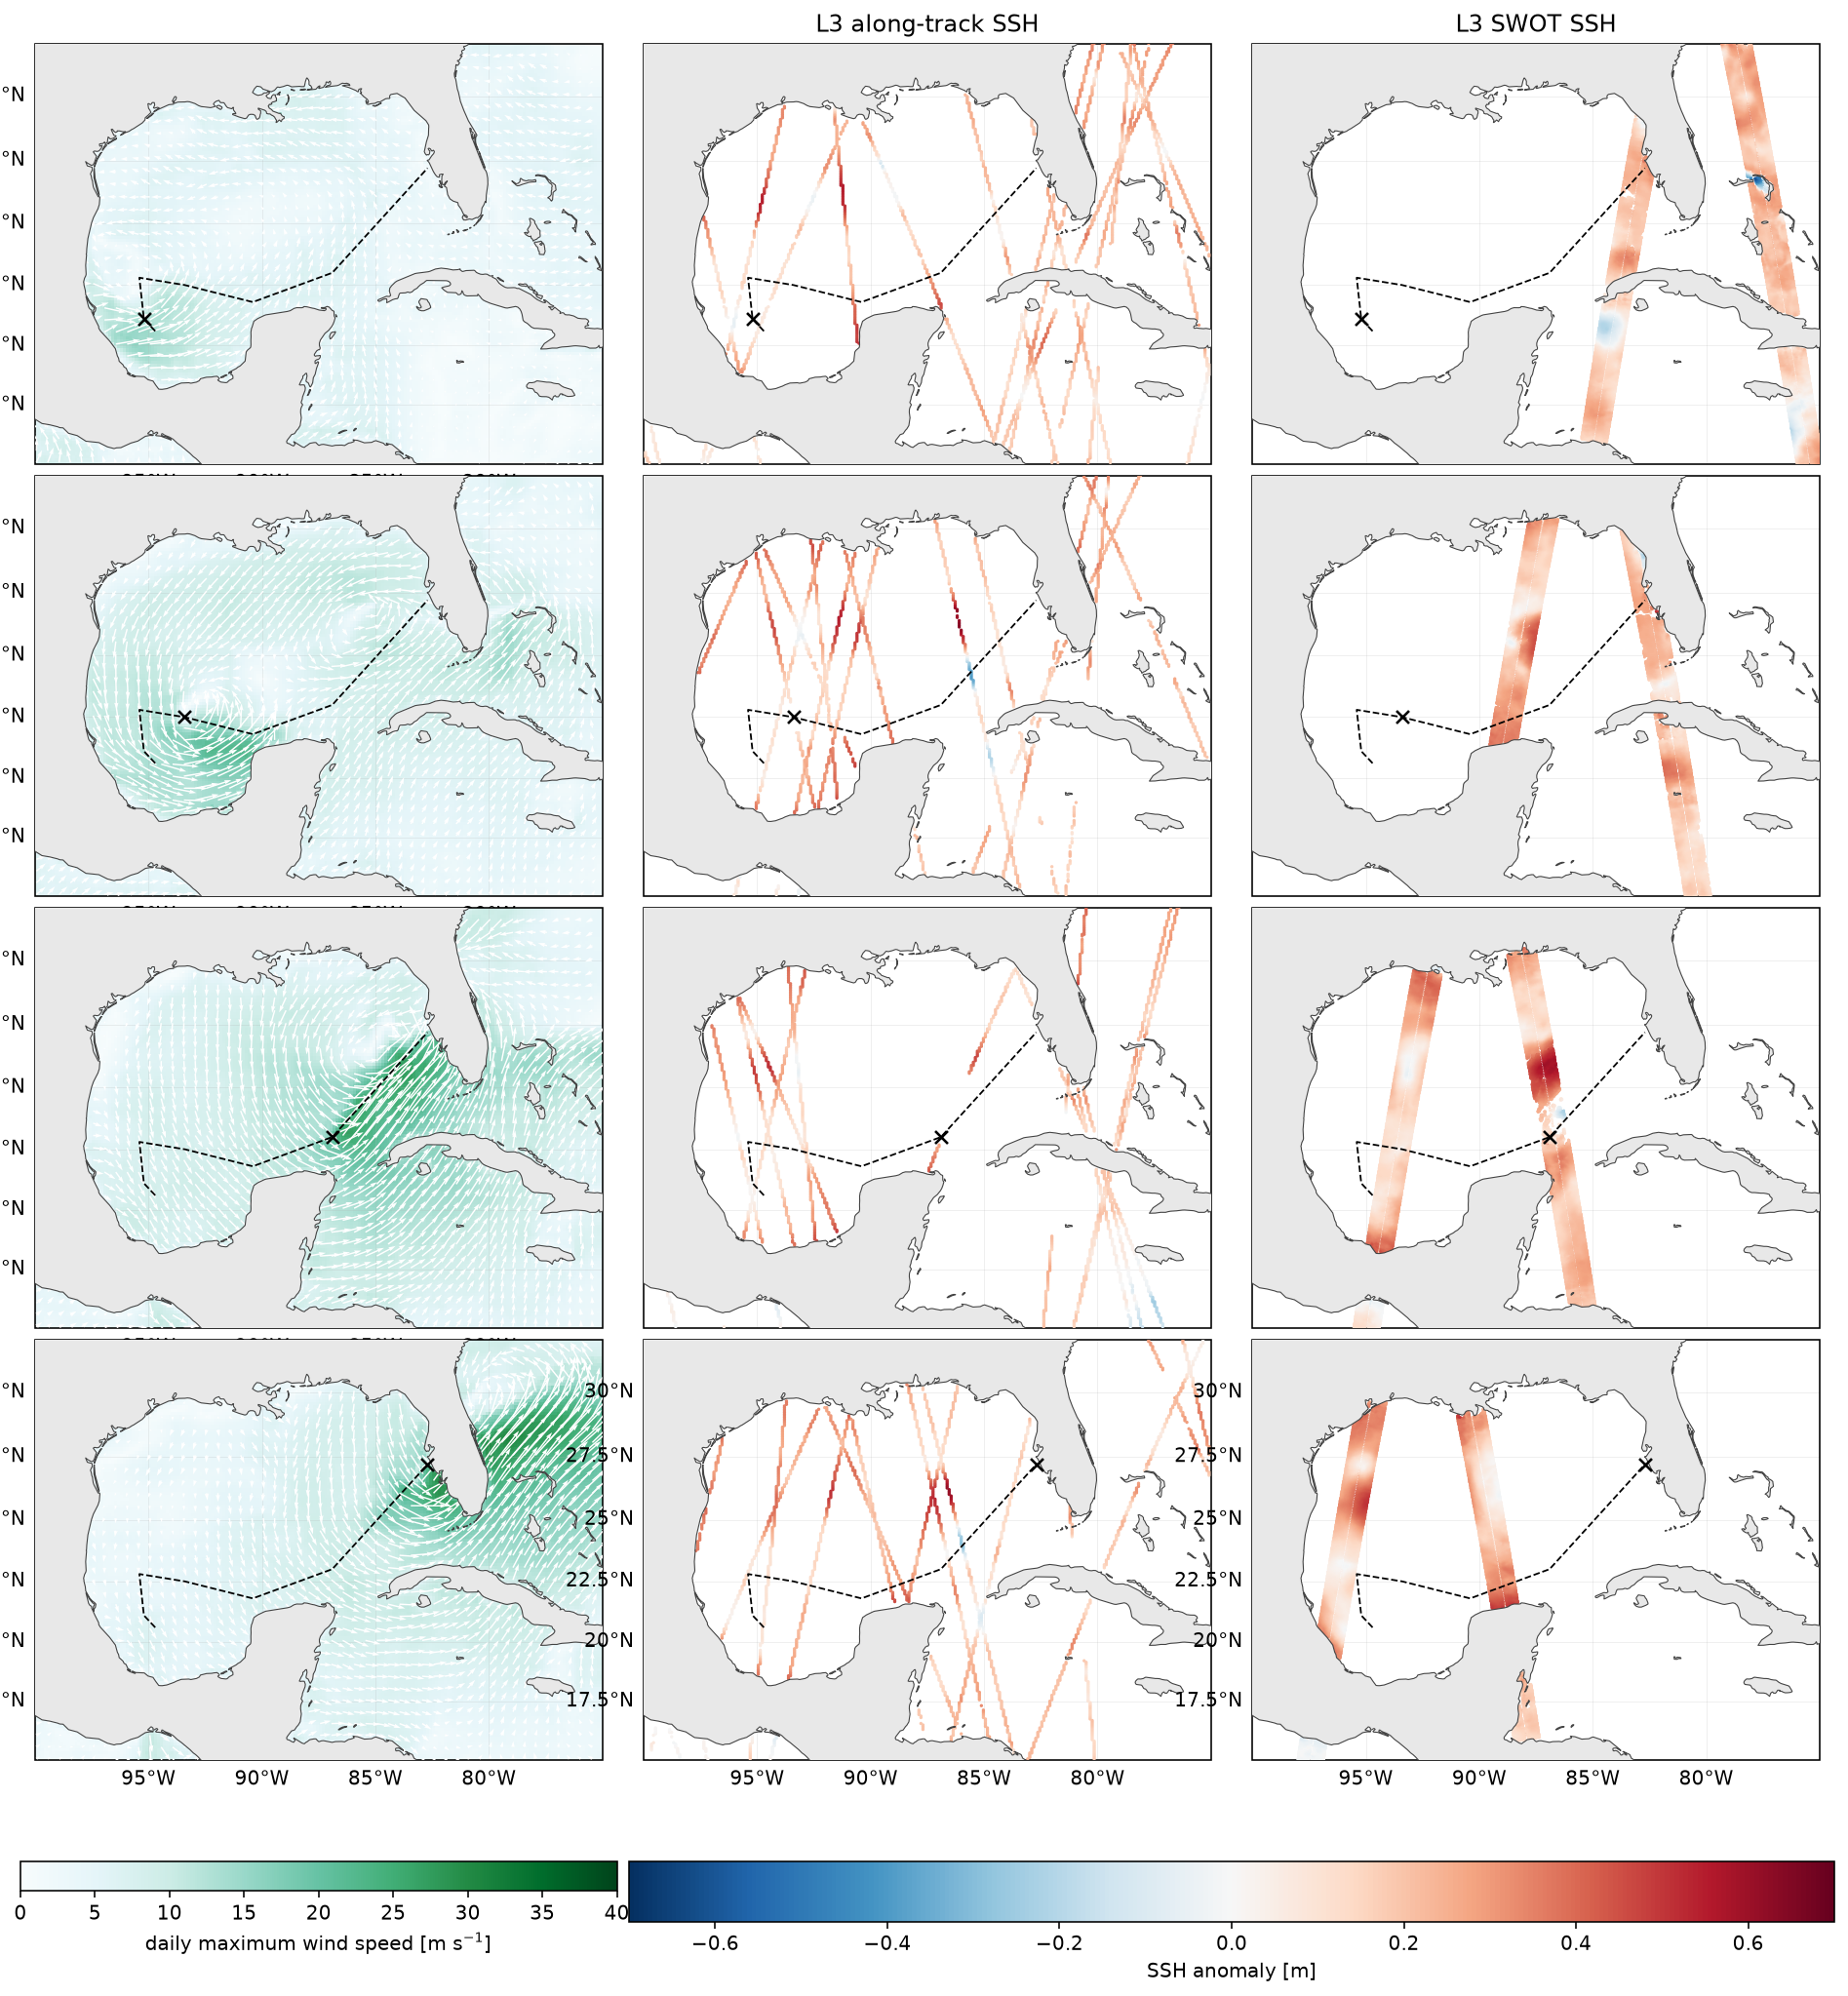

Closed datasets and figure.


In [4]:
from IPython.display import display
figure = make_figure(rows, DEFAULT_DATES)
display_figure(figure)
close_data(rows)
import matplotlib.pyplot as plt
plt.close(figure)
print("Closed datasets and figure.")